# Barbados R.O.A.D. — Qwen VL OCR + **5-Fold LoRA Ensemble**

Patched from the single-notebook VLM port. Changes vs. the original:

**Tier-1 correctness fixes**
1. **Unified image preprocessing** — train and inference now use the *same* high-res
   resize ladder (`load_image`). The old train/infer mismatch was a distribution
   leak that hurt character recognition.
2. **Robust label masking** — the assistant turn is masked by tokenizing the prompt
   half with `add_generation_prompt=True` and masking that many leading tokens
   (exact), instead of the fragile subsequence match. A counter reports any failures.
3. **Best-checkpoint selection** — `load_best_model_at_end` on `eval_loss` instead of
   blindly keeping the last step.
4. **Safer generation** — `repetition_penalty` + `no_repeat_ngram_size` to kill
   degenerate loops, `MAX_NEW_TOKENS=256` so long transcriptions aren't truncated.

**Vision-side LoRA** (`CFG.LORA_VISION`) — also adapts the vision tower + merger, not
just the language projections. Targets are discovered programmatically. A/B it against
the language-only run on the honest OOF CV.

**Streaming (memory-bounded)** — each fold trains, predicts the test set, saves a tiny
CSV, then frees its model + GPU + on-disk checkpoints before the next fold. Only one
model is resident at a time (fits a 14B base). The medoid vote is rebuilt from the saved
predictions with no model in memory.

**Faster inference** — OOF and test are batched (`CFG.BATCH_SIZE`).
**Image augmentation** (additive, TRAIN only) — each augmented copy passes through a seeded, label-preserving
**Tier-1** (brightness/contrast/gamma, parchment tint + desaturate, vignette, stroke erode/dilate, show-through,
Gaussian noise, JPEG recompression) + **Tier-2** (small rotation, shear, elastic warp, height jitter, paper
padding) stack. Every effect is independently toggleable via `CFG.AUG_*` with its own probability and magnitude;
seeds are per-row so copies are reproducible. Cell 6b previews the stack. A/B each effect on OOF.

**Submission** — `submission.csv`: the confidence-weighted medoid over the 5 folds' clean predictions.

**Confidence-weighted ensemble** — every fold's generation now also returns a
length-normalized sequence confidence (from its own token log-probs). The medoid
vote in Cell 11 is weighted by these confidences, so a confident fold's transcription
pulls the consensus toward itself more than a low-confidence one, instead of every
voter counting equally.

**5-fold ensemble**
- `KFold(5)` over the full training set → 5 LoRA adapters.
- **Honest out-of-fold CV** using the competition metric (0.5·WER + 0.5·CER).
- `CFG.TRAIN_FOLDS` lets you train a subset of folds if the Kaggle time budget is tight.
- Inference ensembling via `CFG.ENSEMBLE`:
  - `"soup"` (default): weight-space average of the 5 adapters → one model, **single**
    inference pass. Cheap and effective for LoRA.
  - `"vote"`: generate from each fold, keep the **medoid** hypothesis (min mean CER to
    the others). Slower (5× inference) but pure output-space ensembling.

Attach the same three inputs (competition data, base model, offline wheels) and edit
`CFG` paths as before.


In [1]:
# =========================================================
# Cell 1 — OFFLINE install from the wheels dataset
# =========================================================
import os, sys, subprocess, glob

os.environ["HF_HUB_OFFLINE"]         = "1"
os.environ["TRANSFORMERS_OFFLINE"]   = "1"
os.environ["HF_DATASETS_OFFLINE"]    = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import glob as _glob
import os as _os
WHEELS = "/kaggle/input/datasets/haniagamal/teleco-wheels/wheels"
if not _glob.glob(_os.path.join(WHEELS, "*.whl")):
    _hits = _glob.glob("/kaggle/input/**/*.whl", recursive=True)
    if _hits:
        WHEELS = _os.path.dirname(sorted(_hits, key=len)[0])
print("wheels dir:", WHEELS, "  found:",
      len(_glob.glob(_os.path.join(WHEELS, "*.whl"))), "wheels")

wheels dir: /kaggle/input/datasets/haniagamal/teleco-wheels/wheels   found: 84 wheels


In [2]:
%%capture
!pip uninstall -y torchao
!pip install --no-index --find-links {WHEELS} \
    transformers datasets peft trl jiwer timm librosa soundfile \
    accelerate bitsandbytes huggingface_hub torchao==0.16
print("Dependencies installed (offline).")

In [3]:
# =========================================================
# Cell 2 — imports
# =========================================================
import ast, glob, json, shutil, gc
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob as _glob
from tqdm.auto import tqdm
from sklearn.model_selection import KFold

import transformers
from datasets import Dataset
from transformers import AutoProcessor, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, PeftModel

def _auto_vlm_class():
    for name in ("AutoModelForImageTextToText", "AutoModelForVision2Seq"):
        if hasattr(transformers, name):
            return getattr(transformers, name)
    raise ImportError("no AutoModelForImageTextToText / AutoModelForVision2Seq")
AutoVLM = _auto_vlm_class()

print("transformers", transformers.__version__, "| VLM class:", AutoVLM.__name__)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| bf16", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transformers 5.0.0 | VLM class: AutoModelForImageTextToText
torch 2.10.0+cu128 | cuda True | bf16 True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [4]:
# =========================================================
# Cell 3 — CFG
# =========================================================
class CFG:
    WHEELS_DIR = WHEELS   # (fixed: original referenced an undefined WHEELS_DIR)

    # ---- inputs ----
    BASE_MODEL_PATH = "/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1"
    
    MODEL_PATHS = [   
        "/kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/7b-instruct/2",
        "/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1",
        "/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1",
    ]
    
    DATA_DIR    = "/kaggle/input/datasets/haniagamal/road-barbados"
    TRAIN_CSV   = None
    TEST_CSV    = None
    IMAGES_DIR  = None
    AUTODISCOVER = True

    # ---- outputs ----
    OUTPUT_DIR     = "/kaggle/working/qwen-vl-ocr"
    FINAL_DIR      = "/kaggle/working/qwen-vl-ocr/final"   # adapters -> FINAL_DIR/fold{k}
    SUBMISSION_CSV     = "/kaggle/working/submission.csv"        # clean confidence-weighted medoid
    PREDS_DIR      = "/kaggle/working/fold_preds"   # tiny per-fold test-prediction CSVs
    KEEP_ADAPTERS  = True   # False -> delete each fold's adapter+checkpoints after use (free disk/output)
    ADAPTERS_DIR   = None    # DO_TRAIN=False: dir with fold0/.. ; None -> autodiscover under /kaggle/input

    # ---- training ----
    MODEL_ID                     = None
    PER_DEVICE_TRAIN_BATCH_SIZE  = 4
    GRADIENT_ACCUMULATION_STEPS  = 1
    NUM_TRAIN_EPOCHS             = 1
    LEARNING_RATE                = 2e-4
    DATALOADER_NUM_WORKERS       = 4
    MAX_PIXELS                   = 2_000_000    # raised: handwriting needs resolution
    MIN_PIXELS                   = 256*28*28   # ~200k px floor: stop small strips downscaling to mush
    ATTN_IMPL                    = None
    USE_BF16                     = True
    R                            = 32           # raised from 16
    LORA_ALPHA                   = 64           # raised from 32 (alpha = 2*r)
    LORA_DROPOUT                 = 0.05
    LORA_VISION                  = True   # also LoRA the vision tower + merger (grounding).
                                          # Set False for the language-only A/B baseline.
    # ---- augmentation (TRAIN only, additive) — Tier-1 photometric/degradation + Tier-2 geometric ----
    #   Every aug is independently toggleable with its own trigger prob (_P) and magnitude. All are
    #   LABEL-PRESERVING (glyphs stay legible & in-frame). Seeded per row -> fully reproducible.
    USE_AUGMENT   = True
    AUG_COPIES    = 1      # augmented copies added per original (originals always kept)
    # -- Edge blur: ALWAYS applied FIRST (before every other aug), blurs the UPPER
    #    AUG_CBLUR_FRAC and LOWER AUG_CBLUR_FRAC of the HEIGHT so later augs act on it --
    AUG_CBLUR   = False;  AUG_CBLUR_P   = 1.0;  AUG_CBLUR_FRAC    = 0.2;  AUG_CBLUR_RADIUS = 15.
    # -- Tier 2: geometric (white fill; nothing clipped) --
    AUG_ROTATE  = True;  AUG_ROTATE_P  = 0.5;  AUG_ROTATE_DEG    = 4.0                                # residual skew +/- deg
    AUG_SHEAR   = True;  AUG_SHEAR_P   = 0.4;  AUG_SHEAR_MAX     = 0.15                               # horizontal shear factor
    AUG_ELASTIC = True;  AUG_ELASTIC_P = 0.4;  AUG_ELASTIC_ALPHA = 6.0;  AUG_ELASTIC_SIGMA = 8.0      # hand wobble (needs scipy)
    AUG_HJITTER = True;  AUG_HJITTER_P = 0.4;  AUG_HJITTER_FRAC  = 0.12                               # height +/- frac
    AUG_PAD     = True;  AUG_PAD_P     = 0.3;  AUG_PAD_FRAC      = 0.06                               # paper margin, each side
    # -- Tier 1: photometric / degradation --
    AUG_PHOTO   = True;  AUG_PHOTO_P   = 0.7;  AUG_BRIGHT = 0.20;  AUG_CONTRAST = 0.20;  AUG_GAMMA = 1.4
    AUG_TINT    = True;  AUG_TINT_P    = 0.5;  AUG_TINT_MAX = 0.12;  AUG_DESAT_MAX = 0.40             # parchment tone + desaturate
    AUG_ILLUM   = True;  AUG_ILLUM_P   = 0.4;  AUG_ILLUM_MAX = 0.35                                   # uneven lighting / vignette
    AUG_STROKE  = True;  AUG_STROKE_P  = 0.35                                                         # 1px erode/dilate (pen pressure)
    AUG_BLEED   = True;  AUG_BLEED_P   = 0.25;  AUG_BLEED_ALPHA = 0.12                                # faint show-through
    AUG_NOISE   = True;  AUG_NOISE_P   = 0.5;  AUG_NOISE_STD = 0.1                                   # additive Gaussian (frac of 255)
    AUG_JPEG    = True;  AUG_JPEG_P    = 0.4;  AUG_JPEG_QMIN = 40;  AUG_JPEG_QMAX = 80                # recompression artifacts
    DEBUG                        = False
    SEED                         = 42
    EVAL_STEPS                   = 100
    SAVE_TOTAL_LIMIT             = 2
    EARLYSTOP_FRAC               = 0.4   # frac of each fold's VAL held out for checkpoint selection
    # ---- corrupted images: excluded from BOTH training and validation (dropped before KFold) ----
    CORRUPT_IDS = {
        "79tMUVyfIdy3GzkG",  "F8DYDDp2AvW9Dytw", "JU7lRwk3jKkus24Z", "VmrEALeZiP1Y6nF9", "t0UrASljcgzvBAnO",
    }

    # ---- k-fold / ensemble ----
    N_FOLDS      = 5
    TRAIN_FOLDS  = [0, ]   # train a subset (e.g. [0,1,2]) if time-limited
    ENSEMBLE     = "vote"            # "soup" (weight-space avg) or "vote" (medoid)
    RUN_OOF_CV   = True              # compute honest out-of-fold competition metric

    # ---- inference / generation ----
    MAX_NEW_TOKENS       = 256       # raised from 128 (avoid truncating long lines)
    NUM_BEAMS            = 3
    BATCH_SIZE           = 4         # images per generate() call for OOF/test (lower if OOM)
    REPETITION_PENALTY   = 1.2      # NEW: kill degenerate repetition loops
    NO_REPEAT_NGRAM_SIZE = 6         # NEW
    # ---- resolution TTA: transcribe each image at several scale factors; each
    #      (model-size x scale) becomes its own voter COLUMN in the per-fold file. ----
    USE_TTA_RES     = True
    TTA_RESOLUTIONS = [1.0, ]   # scale factors applied to the loaded strip ([1.0] = off)

    DEVICE               = "auto"
    INFER_USE_BF16       = True      # match training precision (was False)

    # ---- eval metric ----
    WER_WEIGHT = 0.5
    CER_WEIGHT = 0.5

    # ---- flow control ----
    DO_TRAIN = True
    DO_INFER = True

    OCR_PROMPT = (
        "This is not modern English, Transcribe the handwriting exactly. Keep the wrong spelling, abbreviations, and marks (^, ff, unusual letters)."
        "Do not modernize or correct anything."
    )

MODEL_SRC = CFG.MODEL_ID or CFG.BASE_MODEL_PATH
print("Model source:", MODEL_SRC)
print("Folds to train:", CFG.TRAIN_FOLDS, "| ensemble:", CFG.ENSEMBLE)

Model source: /kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1
Folds to train: [0] | ensemble: vote


In [5]:
# =========================================================
# Cell 4 — resolve & sanity-check paths
# =========================================================
def _first_existing(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def _find_under(root, filename):
    hits = _glob(os.path.join(root, "**", filename), recursive=True)
    return hits[0] if hits else None

def resolve_paths(cfg):
    train_csv = cfg.TRAIN_CSV or os.path.join(cfg.DATA_DIR, "Train.csv")
    test_csv  = cfg.TEST_CSV  or os.path.join(cfg.DATA_DIR, "Test.csv")
    images    = cfg.IMAGES_DIR or _first_existing([
        os.path.join(cfg.DATA_DIR, "images", "images"),
        os.path.join(cfg.DATA_DIR, "images"),
    ]) or os.path.join(cfg.DATA_DIR, "images", "images")

    if cfg.AUTODISCOVER:
        if not os.path.exists(train_csv):
            train_csv = _find_under("/kaggle/input", "Train.csv") or train_csv
        if not os.path.exists(test_csv):
            test_csv = _find_under("/kaggle/input", "Test.csv") or test_csv
        if not os.path.isdir(images):
            cand = _glob("/kaggle/input/**/*.jpg", recursive=True)
            if cand:
                images = os.path.dirname(cand[0])
    return train_csv, test_csv, images

TRAIN_CSV, TEST_CSV, IMAGES_DIR = resolve_paths(CFG)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print("TRAIN_CSV :", TRAIN_CSV,  "->", os.path.exists(TRAIN_CSV))
print("TEST_CSV  :", TEST_CSV,   "->", os.path.exists(TEST_CSV))
print("IMAGES_DIR:", IMAGES_DIR, "->", os.path.isdir(IMAGES_DIR))
print("BASE_MODEL:", MODEL_SRC,  "->", os.path.isdir(MODEL_SRC))
assert os.path.exists(TRAIN_CSV), "Train.csv not found"
assert os.path.isdir(IMAGES_DIR), "images dir not found"
assert os.path.isdir(MODEL_SRC),  "base model dir not found"

TRAIN_CSV : /kaggle/input/datasets/haniagamal/road-barbados/Train.csv -> True
TEST_CSV  : /kaggle/input/datasets/haniagamal/road-barbados/Test.csv -> True
IMAGES_DIR: /kaggle/input/datasets/haniagamal/road-barbados/images/images -> True
BASE_MODEL: /kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1 -> True


In [6]:
# =========================================================
# Cell 5 — utils
# =========================================================
def clean_label(x):
    return " ".join(str(x).replace("\n", " ").split()).strip()

def clean_output(text: str) -> str:
    text = str(text)
    for tag in ["assistant", "user", "<|assistant|>", "<|user|>"]:
        if tag in text:
            text = text.split(tag)[-1]
    return " ".join(text.split()).strip()

# --- UNIFIED resize ladder: identical for train AND inference ---
# (Removed the train/infer mismatch. High-res because historic handwriting
#  loses legibility when downscaled. Keep MAX_PIXELS high enough that the
#  processor does not re-shrink these.)
def load_image(path):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    aspect = w / h
    if   aspect > 10: img.thumbnail((2048, 384))
    elif aspect > 5:  img.thumbnail((2048, 512))
    elif aspect > 3:  img.thumbnail((1600, 640))
    else:             img.thumbnail((1536, 768))
    return img

# back-compat aliases so any stray call still works
load_image_train = load_image
load_image_infer = load_image

def _scale_tf(f):
    # Resolution-TTA transform: rescale a loaded PIL strip by factor f (bicubic).
    # f == 1.0 -> None (no-op, uses the plain load_image output).
    if abs(float(f) - 1.0) < 1e-6:
        return None
    def _tf(img):
        w, h = img.size
        return img.resize((max(1, int(round(w*f))), max(1, int(round(h*f)))), Image.BICUBIC)
    return _tf


def _otsu(gray):
    # Otsu threshold on a 0..255 grayscale array -> the gray level that best splits
    # ink from (tan parchment) background. Robust to non-white backgrounds, unlike a
    # fixed <200 cutoff which counts parchment itself as ink. Returns the MIDPOINT of
    # the max between-class-variance plateau (stable for near-bimodal strips).
    hist, _ = np.histogram(gray, bins=256, range=(0, 255))
    hist = hist.astype(np.float64); tot = float(gray.size)
    w = np.cumsum(hist); s = np.cumsum(np.arange(256) * hist); sum_all = s[-1]
    wB = w; wF = tot - w
    with np.errstate(divide="ignore", invalid="ignore"):
        mB = np.where(wB > 0, s / wB, 0.0)
        mF = np.where(wF > 0, (sum_all - s) / wF, 0.0)
    between = wB * wF * (mB - mF) ** 2
    between[(wB <= 0) | (wF <= 0)] = -1.0
    idx = np.where(between == between.max())[0]
    return int(round(idx.mean()))



# --- augmentation stack: Tier-1 (photometric/degradation) + Tier-2 (geometric) ---
from PIL import ImageOps, ImageFilter
import io as _io
try:
    from scipy.ndimage import gaussian_filter as _gaussian_filter, map_coordinates as _map_coordinates
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def _photo(arr, rng, b, c, g):
    a = arr / 255.0
    a = np.power(np.clip(a, 0, 1), float(np.exp(rng.uniform(-np.log(g), np.log(g)))))   # gamma
    a = (a - 0.5) * (1.0 + float(rng.uniform(-c, c))) + 0.5                             # contrast
    a = a * (1.0 + float(rng.uniform(-b, b)))                                           # brightness
    return np.clip(a, 0, 1) * 255.0

def _tint(arr, rng, tint_max, desat_max):
    a = (arr / 255.0).copy()
    gray = a.mean(axis=2, keepdims=True)
    d = float(rng.uniform(0, desat_max)); a = a * (1 - d) + gray * d
    a[..., 0] *= 1.0 + float(rng.uniform(0, tint_max))     # warm up reds
    a[..., 2] *= 1.0 - float(rng.uniform(0, tint_max))     # cool down blues -> parchment
    return np.clip(a, 0, 1) * 255.0

def _illumination(arr, rng, imax):
    h, w = arr.shape[:2]
    cx, cy = float(rng.uniform(0, w)), float(rng.uniform(0, h))
    yy, xx = np.mgrid[0:h, 0:w]
    d = np.sqrt(((xx - cx) / max(w, 1)) ** 2 + ((yy - cy) / max(h, 1)) ** 2)
    field = (1.0 - float(imax) * (d / (d.max() + 1e-6))).astype(np.float32)[..., None]
    return np.clip(arr * field, 0, 255)

def _bleed(arr, rng, alpha):
    a = float(rng.uniform(0, alpha))
    return np.clip(arr * (1 - a) + arr[:, ::-1, :] * a, 0, 255)   # faint mirrored show-through

def _elastic(arr, rng, alpha, sigma):
    h, w = arr.shape[:2]
    dx = _gaussian_filter(rng.rand(h, w).astype(np.float32) * 2 - 1, sigma) * alpha
    dy = _gaussian_filter(rng.rand(h, w).astype(np.float32) * 2 - 1, sigma) * alpha
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    coords = [np.clip(yy + dy, 0, h - 1), np.clip(xx + dx, 0, w - 1)]
    out = np.empty_like(arr)
    for ch in range(arr.shape[2]):
        out[..., ch] = _map_coordinates(arr[..., ch], coords, order=1, mode="reflect")
    return out

def _blur(img, rng, frac, radius):
    # Gaussian-blur the UPPER `frac` and the LOWER `frac` of the image HEIGHT
    # (full width), leaving the central band sharp. Label-preserving: pixels
    # only, no geometry change.
    w, h = img.size
    band = max(1, int(round(h * float(frac))))
    img = img.copy()
    # upper band: rows [0, band)
    top = img.crop((0, 0, w, band)).filter(ImageFilter.GaussianBlur(float(radius)))
    img.paste(top, (0, 0))
    # lower band: rows [h-band, h)
    y0 = max(0, h - band)
    bot = img.crop((0, y0, w, h)).filter(ImageFilter.GaussianBlur(float(radius)))
    img.paste(bot, (0, y0))
    return img


def augment_image(img, seed=None):
    # Label-preserving Tier-1 (photometric/degradation) + Tier-2 (geometric) stack.
    # `seed` (per row) makes each augmented copy deterministic and reproducible across runs.
    if not getattr(CFG, "USE_AUGMENT", False):
        return img
    rng = np.random.RandomState(int(seed) & 0x7fffffff) if seed is not None else np.random

    # ===== ALWAYS-FIRST edge blur: upper+lower band (later augs operate on the blurred image) =====
    if getattr(CFG, "AUG_CBLUR", False) and rng.rand() < CFG.AUG_CBLUR_P:
        img = _blur(img, rng, CFG.AUG_CBLUR_FRAC, CFG.AUG_CBLUR_RADIUS)

    # ===== Tier 2 — geometric (PIL; white fill so no glyph is clipped) =====
    if getattr(CFG, "AUG_ROTATE", False) and rng.rand() < CFG.AUG_ROTATE_P:
        img = img.rotate(float(rng.uniform(-CFG.AUG_ROTATE_DEG, CFG.AUG_ROTATE_DEG)),
                         resample=Image.BICUBIC, expand=True, fillcolor=(255, 255, 255))
    if getattr(CFG, "AUG_SHEAR", False) and rng.rand() < CFG.AUG_SHEAR_P:
        sh = float(rng.uniform(-CFG.AUG_SHEAR_MAX, CFG.AUG_SHEAR_MAX)); w, h = img.size
        xshift = abs(sh) * h
        img = img.transform((w + int(round(xshift)), h), Image.AFFINE,
                            (1, sh, -xshift if sh > 0 else 0.0, 0, 1, 0),
                            resample=Image.BICUBIC, fillcolor=(255, 255, 255))
    if getattr(CFG, "AUG_STROKE", False) and rng.rand() < CFG.AUG_STROKE_P:
        img = img.filter(ImageFilter.MinFilter(3) if rng.rand() < 0.5 else ImageFilter.MaxFilter(3))
    if getattr(CFG, "AUG_HJITTER", False) and rng.rand() < CFG.AUG_HJITTER_P:
        w, h = img.size
        f = float(rng.uniform(1 - CFG.AUG_HJITTER_FRAC, 1 + CFG.AUG_HJITTER_FRAC))
        img = img.resize((w, max(1, int(round(h * f)))), Image.BICUBIC)
    if getattr(CFG, "AUG_PAD", False) and rng.rand() < CFG.AUG_PAD_P:
        w, h = img.size; pf = CFG.AUG_PAD_FRAC
        img = ImageOps.expand(img, (int(rng.uniform(0, pf) * w), int(rng.uniform(0, pf) * h),
                                    int(rng.uniform(0, pf) * w), int(rng.uniform(0, pf) * h)),
                              fill=(255, 255, 255))

    arr = np.asarray(img.convert("RGB"), np.float32)
    if getattr(CFG, "AUG_ELASTIC", False) and _HAS_SCIPY and rng.rand() < CFG.AUG_ELASTIC_P:
        arr = _elastic(arr, rng, CFG.AUG_ELASTIC_ALPHA, CFG.AUG_ELASTIC_SIGMA)

    # ===== Tier 1 — photometric / degradation =====
    if getattr(CFG, "AUG_PHOTO", False) and rng.rand() < CFG.AUG_PHOTO_P:
        arr = _photo(arr, rng, CFG.AUG_BRIGHT, CFG.AUG_CONTRAST, CFG.AUG_GAMMA)
    if getattr(CFG, "AUG_TINT", False) and rng.rand() < CFG.AUG_TINT_P:
        arr = _tint(arr, rng, CFG.AUG_TINT_MAX, CFG.AUG_DESAT_MAX)
    if getattr(CFG, "AUG_ILLUM", False) and rng.rand() < CFG.AUG_ILLUM_P:
        arr = _illumination(arr, rng, CFG.AUG_ILLUM_MAX)
    if getattr(CFG, "AUG_BLEED", False) and rng.rand() < CFG.AUG_BLEED_P:
        arr = _bleed(arr, rng, CFG.AUG_BLEED_ALPHA)
    if getattr(CFG, "AUG_NOISE", False) and rng.rand() < CFG.AUG_NOISE_P:
        arr = arr + rng.randn(*arr.shape).astype(np.float32) * (CFG.AUG_NOISE_STD * 255.0)

    out = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    if getattr(CFG, "AUG_JPEG", False) and rng.rand() < CFG.AUG_JPEG_P:
        buf = _io.BytesIO()
        out.save(buf, format="JPEG", quality=int(rng.randint(CFG.AUG_JPEG_QMIN, CFG.AUG_JPEG_QMAX + 1)))
        buf.seek(0); out = Image.open(buf).convert("RGB")
    return out

def resolve_image(base_dir, image_id):
    exact = os.path.join(base_dir, f"{image_id}.jpg")
    if os.path.exists(exact):
        return exact
    matches = _glob(os.path.join(base_dir, f"{image_id}*.jpg"))
    return matches[0] if matches else None

def get_record_id(row):
    value = row.get("ID", row.get("new_id", row.get("new id",
              row.get("id", row.get("trapp_id", "")))))
    if value is None:
        return ""
    value = str(value).strip()
    return "" if value.lower() == "nan" else value

def get_record_text(row):
    return clean_label(row.get("Target", row.get("text", row.get("label", ""))))

def build_image_path(base_dir, record_id):
    return os.path.join(base_dir, f"{record_id}.jpg")

In [7]:
# =========================================================
# Cell 5b — family-agnostic model & processor loaders
# =========================================================
def load_vlm_model(path, dtype, device_map=None):
    base = {"trust_remote_code": True}
    if device_map is not None:
        base["device_map"] = device_map
    if getattr(CFG, "ATTN_IMPL", None):
        base["attn_implementation"] = CFG.ATTN_IMPL
    for dkey in ("dtype", "torch_dtype"):
        try:
            return AutoVLM.from_pretrained(path, **{dkey: dtype}, **base)
        except TypeError:
            continue
        except Exception:
            if "attn_implementation" in base:
                base.pop("attn_implementation")
                try:
                    return AutoVLM.from_pretrained(path, **{dkey: dtype}, **base)
                except TypeError:
                    continue
            raise
    return AutoVLM.from_pretrained(path, **base)


def _repair_preprocessor(path):
    dst = os.path.join("/kaggle/working", "_patched_" + os.path.basename(path.rstrip("/\\")))
    if os.path.isdir(dst):
        shutil.rmtree(dst)
    def _ignore_weights(_d, names):
        return [n for n in names if n.endswith(
            (".safetensors", ".bin", ".pt", ".pth", ".gguf", ".h5", ".msgpack", ".onnx"))]
    shutil.copytree(path, dst, ignore=_ignore_weights)
    pcfg = os.path.join(dst, "preprocessor_config.json")
    cfg = {}
    if os.path.exists(pcfg):
        with open(pcfg, "r") as f:
            cfg = json.load(f)
    prefer = [
        "Qwen2VLImageProcessorFast", "Qwen2_5_VLImageProcessorFast", "Qwen3VLImageProcessorFast",
        "Qwen2VLImageProcessor", "Qwen2_5_VLImageProcessor", "Qwen3VLImageProcessor",
    ]
    avail = [c for c in prefer if hasattr(transformers, c)]
    if avail:
        cfg["image_processor_type"] = avail[0]
        print("[processor-repair] image_processor_type ->", avail[0])
    else:
        cfg.pop("image_processor_type", None)
        print("[processor-repair] removed image_processor_type")
    with open(pcfg, "w") as f:
        json.dump(cfg, f)
    return dst


def load_vlm_processor(path, max_pixels=None, min_pixels=None):
    attempts = [
        dict(use_fast=True),
        dict(use_fast=False),
        dict(use_fast=True,  trust_remote_code=True),
        dict(use_fast=False, trust_remote_code=True),
    ]
    proc, last = None, None
    for kw in attempts:
        try:
            proc = AutoProcessor.from_pretrained(path, **kw); break
        except Exception as e:
            last = e
    if proc is None:
        print("[processor] direct load failed; repairing. cause:", repr(last)[:200])
        patched = _repair_preprocessor(path)
        for kw in attempts:
            try:
                proc = AutoProcessor.from_pretrained(patched, **kw); break
            except Exception as e:
                last = e
    if proc is None:
        raise last
    ip = getattr(proc, "image_processor", None)
    if ip is not None:
        if max_pixels is not None and hasattr(ip, "max_pixels"):
            ip.max_pixels = max_pixels
        if min_pixels is not None and hasattr(ip, "min_pixels"):
            ip.min_pixels = min_pixels
    print("[processor] loaded:", type(proc).__name__,
          "| image_processor:", type(ip).__name__ if ip is not None else None)
    return proc

In [8]:
# =========================================================
# Cell 6 — build the full sample list + KFold split
# =========================================================
def build_samples(df, base_dir):
    corrupt = set(getattr(CFG, "CORRUPT_IDS", ()))
    samples, found, missing, excluded = [], 0, 0, 0
    for _, row in df.iterrows():
        image_id = get_record_id(row)
        label = get_record_text(row)
        if not image_id or not label:
            continue
        if image_id in corrupt:            # drop corrupted images from train + val entirely
            excluded += 1
            continue
        path = resolve_image(base_dir, image_id)
        if path is None:
            missing += 1
            if missing < 5:
                print("[MISSING]", image_id)
            continue
        found += 1
        samples.append({"image": path, "text": label})
    print(f"[DATASET] found={found}, missing={missing}, excluded_corrupt={excluded}")
    return samples

df = pd.read_csv(TRAIN_CSV).sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)
if CFG.DEBUG:
    df = df.iloc[:400]

all_samples = build_samples(df, IMAGES_DIR)
assert len(all_samples) > 0, "EMPTY DATASET"

kf = KFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
FOLDS = list(kf.split(all_samples))
print(f"Total samples: {len(all_samples)} | folds: {CFG.N_FOLDS}")
for k, (tr, va) in enumerate(FOLDS):
    print(f"  fold {k}: train={len(tr)}  val={len(va)}")

# quick label-length sanity check -> informs MAX_NEW_TOKENS
_lens = [len(s["text"]) for s in all_samples]
print(f"label char length: p50={int(np.percentile(_lens,50))} "
      f"p95={int(np.percentile(_lens,95))} p99={int(np.percentile(_lens,99))} max={max(_lens)}")

[DATASET] found=4093, missing=0, excluded_corrupt=5
Total samples: 4093 | folds: 5
  fold 0: train=3274  val=819
  fold 1: train=3274  val=819
  fold 2: train=3274  val=819
  fold 3: train=3275  val=818
  fold 4: train=3275  val=818
label char length: p50=62 p95=85 p99=92 max=108


CORRUPT_IDS: 5


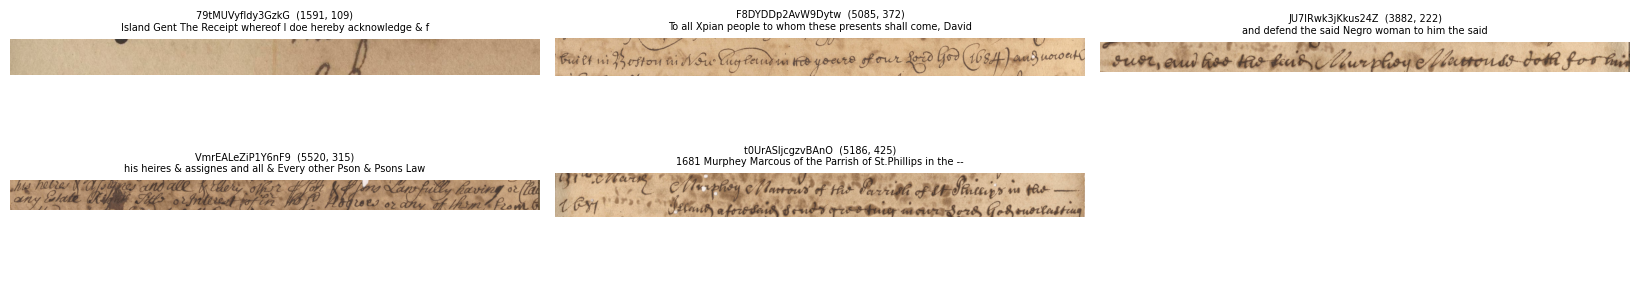

In [9]:
# =========================================================
# Preview CFG.CORRUPT_IDS — the images dropped before KFold
#   Renders each corrupt strip (with its label if present) so you can
#   confirm they're genuinely unusable. Missing/unreadable ones are flagged.
# =========================================================
import matplotlib.pyplot as plt

_cids = sorted(getattr(CFG, "CORRUPT_IDS", ()))
print(f"CORRUPT_IDS: {len(_cids)}")

# label lookup from Train.csv (optional, for context)
try:
    _lab = {get_record_id(r): get_record_text(r)
            for r in pd.read_csv(TRAIN_CSV).to_dict("records")}
except Exception:
    _lab = {}

_cols = 3
_rows = (len(_cids) + _cols - 1) // _cols
fig, axes = plt.subplots(_rows, _cols, figsize=(5.5 * _cols, 1.7 * _rows), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")

_missing = []
for k, cid in enumerate(_cids):
    ax = axes[k // _cols][k % _cols]
    p = resolve_image(IMAGES_DIR, cid)
    if p is None:
        _missing.append(cid)
        ax.set_title(f"{cid}\n[NOT FOUND]", fontsize=7, color="red")
        continue
    try:
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        lab = _lab.get(cid, "")
        ax.set_title(f"{cid}  {img.size}\n{lab[:60]}", fontsize=7)
    except Exception as e:
        _missing.append(cid)
        ax.set_title(f"{cid}\n[UNREADABLE: {type(e).__name__}]", fontsize=7, color="red")

plt.tight_layout(); plt.show()
if _missing:
    print("could not load:", _missing)

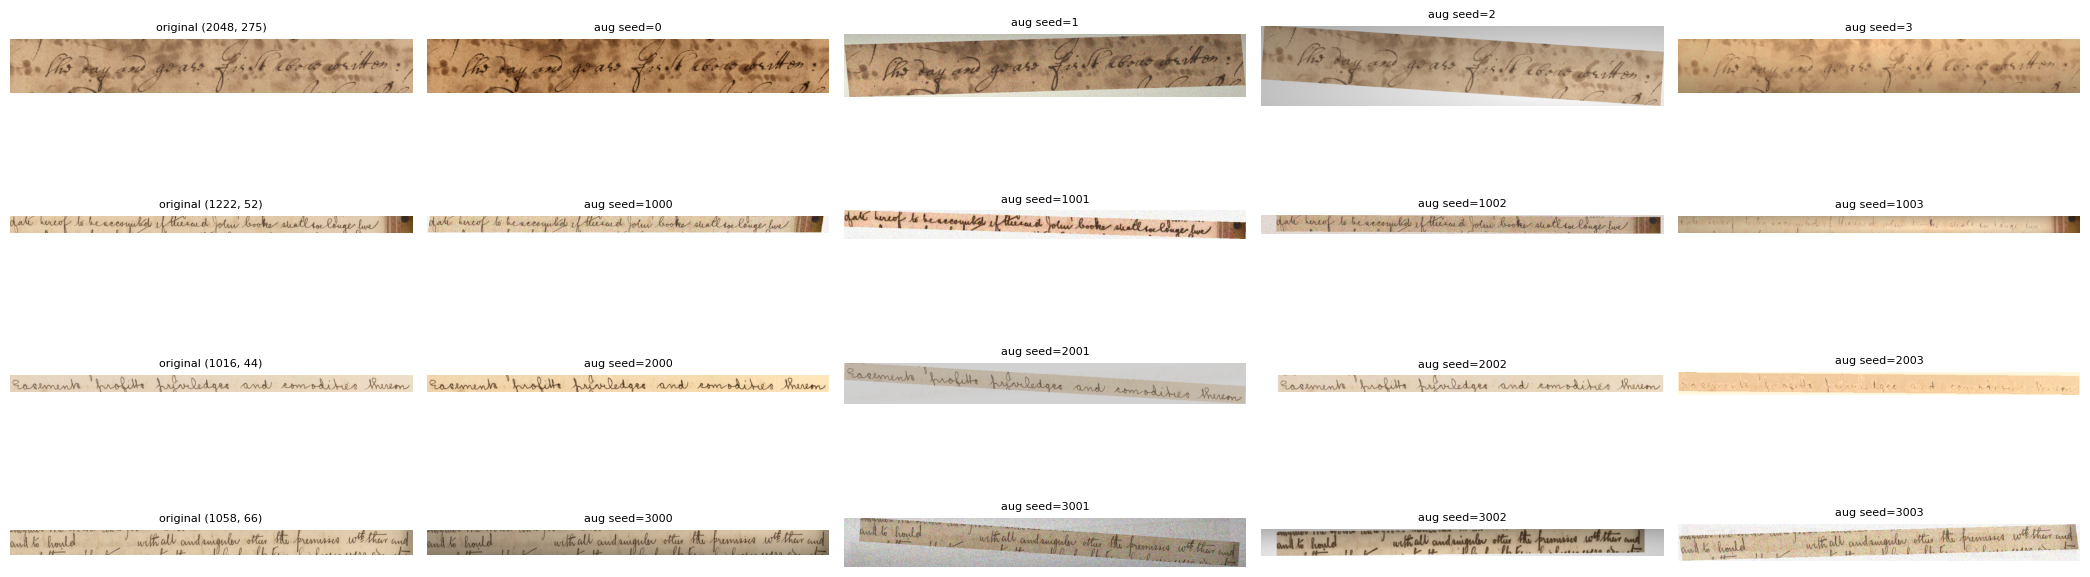

scipy(elastic) available: True | enabled: AUG_ROTATE, AUG_SHEAR, AUG_ELASTIC, AUG_HJITTER, AUG_PAD, AUG_PHOTO, AUG_TINT, AUG_ILLUM, AUG_STROKE, AUG_BLEED, AUG_NOISE, AUG_JPEG


In [10]:
# =========================================================
# Cell 6b — PREVIEW the Tier-1 + Tier-2 augmentation stack on real TRAIN images
#   Each row: the original strip, then several INDEPENDENTLY-SEEDED augmented copies.
#   Tune the per-aug knobs (AUG_*_P / magnitudes) in Cell 3 and re-run this cell.
# =========================================================
import matplotlib.pyplot as plt
_n, _v = 4, 4                       # rows (images) x augmented variants per image
_samples = all_samples[:_n]
fig, axes = plt.subplots(_n, _v + 1, figsize=(4.2 * (_v + 1), 1.8 * _n), squeeze=False)
for r, s in enumerate(_samples):
    orig = load_image(s["image"])
    axes[r][0].imshow(orig); axes[r][0].set_title(f"original {orig.size}", fontsize=8); axes[r][0].axis("off")
    for c in range(_v):
        aug = augment_image(orig, seed=1000 * r + c)
        axes[r][c + 1].imshow(aug); axes[r][c + 1].set_title(f"aug seed={1000 * r + c}", fontsize=8)
        axes[r][c + 1].axis("off")
plt.tight_layout(); plt.show()
_masters = ["AUG_ROTATE", "AUG_SHEAR", "AUG_ELASTIC", "AUG_HJITTER", "AUG_PAD",
            "AUG_PHOTO", "AUG_TINT", "AUG_ILLUM", "AUG_STROKE", "AUG_BLEED", "AUG_NOISE", "AUG_JPEG"]
print("scipy(elastic) available:", _HAS_SCIPY,
      "| enabled:", ", ".join(m for m in _masters if getattr(CFG, m, False)))

In [11]:
# =========================================================
# Cell 7 — collator with ROBUST assistant-boundary label masking
# =========================================================
MASK_FAIL_COUNT = 0   # increments if the prompt-boundary length can't be computed

def collate_fn(examples, processor):
    global MASK_FAIL_COUNT
    images, texts = [], []
    for ex in examples:
        if os.path.exists(ex["image"]):
            img = load_image(ex["image"])
            if CFG.USE_AUGMENT and ex.get("aug", False):   # train rows only; eval/OOF/test stay clean
                img = augment_image(img, ex.get("seed"))
            images.append(img)
            texts.append(ex["text"])
    if len(images) == 0:
        return None

    tokenizer = processor.tokenizer
    full_msgs, prompt_msgs = [], []
    for img, label in zip(images, texts):
        user_turn = {"role": "user", "content": [
            {"type": "text", "text": CFG.OCR_PROMPT},
            {"type": "image", "image": img},
        ]}
        full_msgs.append([user_turn,
            {"role": "assistant", "content": [{"type": "text", "text": label}]}])
        prompt_msgs.append([user_turn])

    texts_out = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
                 for m in full_msgs]

    batch = processor(text=texts_out, images=images,
                      padding=True, truncation=True, return_tensors="pt")

    input_ids = batch["input_ids"]
    labels = input_ids.clone()

    # --- mask everything up to the start of the assistant answer ---
    # Tokenize the prompt half (user turn + generation prompt) alone; its length
    # is exactly how many leading tokens to mask. Robust to BPE boundary merges.
    for i, pm in enumerate(prompt_msgs):
        try:
            prompt_txt = processor.apply_chat_template(pm, tokenize=False,
                                                       add_generation_prompt=True)
            prompt_ids = processor(text=[prompt_txt], images=[images[i]],
                                   return_tensors="pt", truncation=True)["input_ids"][0]
            # strip padding count difference: compare non-pad prompt length
            n_prompt = int((prompt_ids != tokenizer.pad_token_id).sum().item())
            labels[i, :n_prompt] = -100
        except Exception:
            MASK_FAIL_COUNT += 1

    labels[labels == tokenizer.pad_token_id] = -100

    image_token = getattr(processor, "image_token", None) or "<|image_pad|>"
    image_token_id = tokenizer.convert_tokens_to_ids(image_token)
    if isinstance(image_token_id, int) and image_token_id >= 0:
        labels[labels == image_token_id] = -100

    batch["labels"] = labels
    return batch

In [12]:
# =========================================================
# Cell 8 — predict() + competition metric helpers
# CONFIDENCE: every generation now also returns a length-normalized
# sequence confidence in (0, 1], computed from the model's own token
# log-probs via `compute_transition_scores` (works for both beam search
# and greedy decoding). This confidence is what drives the
# confidence-weighted ensemble in Cell 11.
# =========================================================
def _sequence_confidences(model, tokenizer, output, prompt_len):
    """Per-sequence confidence = exp(mean token log-prob) over the
    generated (non-pad) tokens. Higher = the model was more sure of its
    own transcription. Works uniformly for beam search (num_beams>1) and
    greedy decoding (num_beams=1) via HF's compute_transition_scores."""
    beam_indices = getattr(output, "beam_indices", None)
    transition_scores = model.compute_transition_scores(
        output.sequences, output.scores, beam_indices, normalize_logits=True
    )  # (batch, gen_len) log-prob of the chosen token at each generated step
    gen_ids = output.sequences[:, prompt_len:]
    pad_id = tokenizer.pad_token_id
    if pad_id is None:
        pad_id = tokenizer.eos_token_id
    valid = (gen_ids != pad_id) & torch.isfinite(transition_scores)
    counts = valid.sum(dim=1).clamp(min=1)
    summed = torch.where(valid, transition_scores,
                          torch.zeros_like(transition_scores)).sum(dim=1)
    mean_logprob = summed / counts
    conf = torch.exp(mean_logprob).clamp(0.0, 1.0)
    # transition_scores are per-token log-probs (normalize_logits=True); the
    # per-char mapping reuses them so no extra forward pass is needed.
    tok_lp = torch.where(valid, transition_scores,
                         torch.full_like(transition_scores, float("-inf")))
    return conf.detach().float().cpu().tolist(), tok_lp.detach().float().cpu()


def _clean_with_conf(raw_text, raw_conf):
    """Mirror clean_output() on a (string, per-char-conf) pair so the
    returned confidence list stays aligned to the cleaned text char-for-char.
    clean_output does: strip role tags, then collapse whitespace + strip."""
    text = str(raw_text)
    conf = list(raw_conf)
    if len(conf) != len(text):                     # safety: pad/trim to match
        if len(conf) < len(text):
            conf = conf + [0.0] * (len(text) - len(conf))
        else:
            conf = conf[:len(text)]
    for tag in ["assistant", "user", "<|assistant|>", "<|user|>"]:
        pos = text.rfind(tag)
        if pos != -1:
            cut = pos + len(tag)
            text = text[cut:]; conf = conf[cut:]
    # collapse runs of whitespace to a single space; keep first char's conf
    out_c, out_f = [], []
    i, n = 0, len(text)
    while i < n:
        ch = text[i]
        if ch.isspace():
            j = i
            while j < n and text[j].isspace(): j += 1
            out_c.append(" "); out_f.append(conf[i])
            i = j
        else:
            out_c.append(ch); out_f.append(conf[i]); i += 1
    # strip() leading/trailing space
    while out_c and out_c[0] == " ": out_c.pop(0); out_f.pop(0)
    while out_c and out_c[-1] == " ": out_c.pop(); out_f.pop()
    return "".join(out_c), out_f


def _char_confidences(tokenizer, gen_ids_row, tok_logprob_row, pad_id):
    """Map each generated token's log-prob to the characters it decodes to,
    via incremental decoding (robust to multi-byte / byte-level BPE tokens).
    Returns (raw_text, raw_char_conf) aligned char-for-char BEFORE cleaning."""
    ids = gen_ids_row.tolist() if hasattr(gen_ids_row, "tolist") else list(gen_ids_row)
    lps = tok_logprob_row.tolist() if hasattr(tok_logprob_row, "tolist") else list(tok_logprob_row)
    import math
    running, prev, char_conf = [], "", []
    for k, tid in enumerate(ids):
        if tid == pad_id:
            break
        running.append(tid)
        cur = tokenizer.decode(running, skip_special_tokens=True)
        added = len(cur) - len(prev)
        lp = lps[k] if k < len(lps) else 0.0
        p = math.exp(lp) if (lp is not None and math.isfinite(lp)) else 0.0
        p = min(max(p, 0.0), 1.0)
        if added > 0:
            char_conf.extend([p] * added)
        elif added < 0:                            # rare: a token shortened the string
            char_conf = char_conf[:len(cur)]
        prev = cur
    return prev, char_conf


def predict(model, processor, image,
            max_new_tokens=None, num_beams=None):
    max_new_tokens = max_new_tokens or CFG.MAX_NEW_TOKENS
    num_beams      = num_beams if num_beams is not None else CFG.NUM_BEAMS
    messages = [{"role": "user", "content": [
        {"type": "text", "text": CFG.OCR_PROMPT},
        {"type": "image", "image": image},
    ]}]
    prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt], images=[image], return_tensors="pt", padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False, temperature=0.0,
            num_beams=num_beams,
            repetition_penalty=CFG.REPETITION_PENALTY,
            no_repeat_ngram_size=CFG.NO_REPEAT_NGRAM_SIZE,
            output_scores=True,
            return_dict_in_generate=True,
        )
    prompt_len = inputs["input_ids"].shape[1]
    # decode only the newly generated tokens
    gen = output.sequences[:, prompt_len:]
    tok = processor.tokenizer
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    seq_conf, tok_lp = _sequence_confidences(model, tok, output, prompt_len)
    conf = seq_conf[0]
    raw, raw_cc = _char_confidences(tok, gen[0], tok_lp[0], pad_id)
    text, char_conf = _clean_with_conf(raw, raw_cc)
    return text, conf, char_conf


def _predict_batch(model, processor, images, max_new_tokens=None, num_beams=None):
    # Transcribe a LIST of PIL images in ONE generate() call (~BATCH_SIZE x faster).
    # Returns (texts, confidences) — parallel lists.
    max_new_tokens = max_new_tokens or CFG.MAX_NEW_TOKENS
    num_beams      = num_beams if num_beams is not None else CFG.NUM_BEAMS
    prompts = [processor.apply_chat_template(
        [{"role": "user", "content": [
            {"type": "text", "text": CFG.OCR_PROMPT},
            {"type": "image", "image": im}]}],
        tokenize=False, add_generation_prompt=True) for im in images]
    tok = processor.tokenizer
    old_side = tok.padding_side
    tok.padding_side = "left"          # batched decoder generation needs LEFT padding...
    try:
        inputs = processor(text=prompts, images=images, return_tensors="pt", padding=True)
    finally:
        tok.padding_side = old_side     # ...restored so the TRAIN collator stays right-padded
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=0.0, num_beams=num_beams,
            repetition_penalty=CFG.REPETITION_PENALTY, no_repeat_ngram_size=CFG.NO_REPEAT_NGRAM_SIZE,
            output_scores=True, return_dict_in_generate=True)
    prompt_len = inputs["input_ids"].shape[1]
    gen = out.sequences[:, prompt_len:]
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    confs, tok_lp = _sequence_confidences(model, tok, out, prompt_len)
    texts, char_confs = [], []
    for r in range(gen.shape[0]):
        raw, raw_cc = _char_confidences(tok, gen[r], tok_lp[r], pad_id)
        t, cc = _clean_with_conf(raw, raw_cc)
        texts.append(t); char_confs.append(cc)
    return texts, confs, char_confs


def transcribe_paths(model, processor, path_list, transform=None, desc=None):
    # Batched transcription of image PATHS. `transform` optionally maps each PIL image
    # (used for blur TTA); None -> clean load_image.
    # Returns (texts, confidences) — parallel lists, same length/order as path_list.
    # Missing/unreadable paths get text="" and confidence=0.0 (lowest possible weight
    # in the downstream confidence-weighted ensemble).
    bs = getattr(CFG, "BATCH_SIZE", 8)
    out  = [""] * len(path_list)
    conf = [0.0] * len(path_list)
    cconf = [[] for _ in range(len(path_list))]
    idxs = [i for i, p in enumerate(path_list) if p and os.path.exists(p)]
    for b in tqdm(range(0, len(idxs), bs), desc=desc, leave=False):
        chunk = idxs[b:b + bs]
        imgs = []
        for i in chunk:
            im = load_image(path_list[i])
            if transform is not None:
                im = transform(im)
            imgs.append(im)
        texts, confs, cconfs = _predict_batch(model, processor, imgs)
        for i, r, c, cc in zip(chunk, texts, confs, cconfs):
            out[i] = r
            conf[i] = c
            cconf[i] = cc
    return out, conf, cconf


def _predict_batch_text(model, processor, images, max_new_tokens=None, num_beams=None):
    # Like _predict_batch but TEXT ONLY: no output_scores / confidence work
    # (faster, less memory) -- used when we only need the transcription string.
    max_new_tokens = max_new_tokens or CFG.MAX_NEW_TOKENS
    num_beams      = num_beams if num_beams is not None else CFG.NUM_BEAMS
    prompts = [processor.apply_chat_template(
        [{"role": "user", "content": [
            {"type": "text", "text": CFG.OCR_PROMPT},
            {"type": "image", "image": im}]}],
        tokenize=False, add_generation_prompt=True) for im in images]
    tok = processor.tokenizer
    old_side = tok.padding_side; tok.padding_side = "left"
    try:
        inputs = processor(text=prompts, images=images, return_tensors="pt", padding=True)
    finally:
        tok.padding_side = old_side
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=0.0,
                             num_beams=num_beams, repetition_penalty=CFG.REPETITION_PENALTY,
                             no_repeat_ngram_size=CFG.NO_REPEAT_NGRAM_SIZE)
    gen = out[:, inputs["input_ids"].shape[1]:]
    return [clean_output(t) for t in processor.batch_decode(gen, skip_special_tokens=True)]


def transcribe_texts(model, processor, path_list, transform=None, desc=None):
    # Text-only batched transcription of image PATHS (no confidence). Returns list[str],
    # same length/order as path_list; missing paths -> "".
    bs = getattr(CFG, "BATCH_SIZE", 8)
    out = [""] * len(path_list)
    idxs = [i for i, p in enumerate(path_list) if p and os.path.exists(p)]
    for b in tqdm(range(0, len(idxs), bs), desc=desc, leave=False):
        chunk = idxs[b:b + bs]
        imgs = []
        for i in chunk:
            im = load_image(path_list[i])
            if transform is not None: im = transform(im)
            imgs.append(im)
        for i, r in zip(chunk, _predict_batch_text(model, processor, imgs)):
            out[i] = r
    return out


def weighted_wer_cer(refs, hyps):
    import jiwer
    refs = [str(r) for r in refs]
    hyps = ["" if h is None else str(h) for h in hyps]
    return jiwer.wer(refs, hyps), jiwer.cer(refs, hyps)

def comp_metric(refs, hyps):
    wer, cer = weighted_wer_cer(refs, hyps)
    return CFG.WER_WEIGHT * wer + CFG.CER_WEIGHT * cer, wer, cer

def free_cuda(*names):
    for n in names:
        if n in globals():
            del globals()[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [ ]:
# =========================================================
# Cell 9 - ONE SESSION: train ALL CFG.MODEL_PATHS on ONE fold (CFG.TRAIN_FOLDS[0]),
# collect each model's OOF + TEST predictions, TUNE the ensemble weights on that
# fold's OOF (weighted char-ROVER), and APPLY them to the test set. Only one model
# is resident at a time (train -> predict -> free -> next model).
#
# Per-model files are saved under CFG.PREDS_DIR/<model>/fold{K}__{oof,clean}.csv and the
# model-combined test prediction for this fold -> CFG.PREDS_DIR/xmodel_fold{K}.csv .
# Run this once per fold (change CFG.TRAIN_FOLDS), then equal-weight char-ROVER the
# xmodel_fold*.csv across folds for the final submission.
# =========================================================
os.makedirs(CFG.FINAL_DIR, exist_ok=True)
os.makedirs(CFG.PREDS_DIR, exist_ok=True)
import torch.nn as _nn, re as _re

def _vision_linear_names(model):
    keys = []
    for name, mod in model.named_modules():
        if isinstance(mod, _nn.Linear) and any(t in name.lower() for t in ("visual", "vision", "merger")):
            keys.append(name)
    return keys

def build_lora_model(dtype, msrc):
    m = load_vlm_model(msrc, dtype)
    m.to("cuda")
    m.config.use_cache = False
    if msrc in ["/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1", "/kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/32b-instruct/2",]:
        m.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        
    m.enable_input_require_grads()
    targets = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
    if getattr(CFG, "LORA_VISION", False):
        vt = _vision_linear_names(m); targets = targets + vt
        print(f"[lora] LORA_VISION=ON -> +{len(vt)} vision/merger modules")
    else:
        print("[lora] LORA_VISION=OFF -> language-only")
    lora = LoraConfig(r=CFG.R, lora_alpha=CFG.LORA_ALPHA, target_modules=targets,
                      lora_dropout=CFG.LORA_DROPOUT, bias="none", task_type="CAUSAL_LM")
    m = get_peft_model(m, lora); m.print_trainable_parameters()
    return m

def _resolve_adapter(mname, fold):
    """Find this (model, fold)'s saved LoRA adapter dir for inference-only runs.
    Tries the layouts a training run writes / a Kaggle dataset mirrors, and
    autodiscovers under /kaggle/input if ADAPTERS_DIR is None. Returns a dir
    that contains adapter_config.json, or None."""
    import glob as _g
    roots = []
    ad = getattr(CFG, "ADAPTERS_DIR", None)
    if ad:
        roots.append(ad)
    else:
        roots += sorted(_g.glob("/kaggle/input/*")) + sorted(_g.glob("/kaggle/input/*/*"))
    cands = []
    for r in roots:
        cands += [
            os.path.join(r, mname, f"fold{fold}"),
            os.path.join(r, f"fold{fold}", mname),
            os.path.join(r, f"fold{fold}"),
            os.path.join(r, mname),
            r,
        ]
    for c in cands:
        if c and os.path.isfile(os.path.join(c, "adapter_config.json")):
            return c
    # last resort: recursive search for any adapter_config.json mentioning this fold
    for r in roots:
        for cfgp in _g.glob(os.path.join(r, "**", "adapter_config.json"), recursive=True):
            d = os.path.dirname(cfgp)
            if f"fold{fold}" in d.replace("\\", "/"):
                return d
    return None


def load_infer_model(dtype, msrc, mname, fold):
    """Base weights + attached LoRA adapter, merged for fast inference. No training."""
    from peft import PeftModel
    adir = _resolve_adapter(mname, fold)
    if adir is None:
        raise FileNotFoundError(
            f"[infer] no adapter for model={mname} fold={fold} under "
            f"ADAPTERS_DIR={getattr(CFG, 'ADAPTERS_DIR', None)!r}. "
            f"Set CFG.ADAPTERS_DIR to the dataset dir holding fold{fold}/ (or model/fold{fold}/).")
    print(f"[infer] {mname} fold{fold}: loading adapter <- {adir}")
    m = load_vlm_model(msrc, dtype)
    m = PeftModel.from_pretrained(m, adir)
    try:
        m = m.merge_and_unload()          # fold LoRA into base -> plain fast forward
        print("[infer] merged adapter into base weights")
    except Exception as e:
        print(f"[infer] merge_and_unload skipped ({e}); running with PEFT wrapper")
    m.to("cuda"); m.config.use_cache = True; m.eval()
    return m


def _safe_rmtree(path):
    if path and os.path.isdir(path) and os.path.abspath(path).startswith("/kaggle/working"):
        shutil.rmtree(path, ignore_errors=True); return True
    return False

# ---- weighted char-ROVER + scorer (for in-session OOF weight tuning) ----
_NULL = "\x00"
def _xnw(cons, toks):
    n, m = len(cons), len(toks); D = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1): D[i][0] = i
    for j in range(1, m+1): D[0][j] = j
    for i in range(1, n+1):
        ci = cons[i-1]; Di = D[i]; Dp = D[i-1]
        for j in range(1, m+1):
            Di[j] = min(Dp[j-1] + (0 if ci == toks[j-1] else 1), Dp[j]+1, Di[j-1]+1)
    i, j, ops = n, m, []
    while i > 0 or j > 0:
        if i > 0 and j > 0 and D[i][j] == D[i-1][j-1] + (0 if cons[i-1] == toks[j-1] else 1):
            ops.append((i-1, toks[j-1])); i, j = i-1, j-1
        elif i > 0 and D[i][j] == D[i-1][j] + 1: i -= 1
        else: ops.append((None, toks[j-1])); j -= 1
    ops.reverse(); return ops
def _xalign(strings):
    import collections as _cc
    V = len(strings); seqs = [list(s) for s in strings]
    cols = [{0: c} for c in seqs[0]]
    rep = lambda col: _cc.Counter(col.values()).most_common(1)[0][0]
    for v in range(1, V):
        cons = [rep(c) for c in cols]; ops = _xnw(cons, seqs[v]); newcols = []; ci = 0
        for tci, tok in ops:
            if tci is None: newcols.append(({}, tok)); continue
            while ci <= tci: newcols.append((cols[ci], None)); ci += 1
            newcols[-1] = (newcols[-1][0], tok)
        while ci < len(cols): newcols.append((cols[ci], None)); ci += 1
        rebuilt = []
        for col, tok in newcols:
            col = dict(col)
            if tok is not None: col[v] = tok
            rebuilt.append(col)
        cols = rebuilt
    return [[col.get(v, _NULL) for v in range(V)] for col in cols]
def _xvote(cols, weights):
    res = []
    for col in cols:
        agg = {}
        for v, ch in enumerate(col): agg[ch] = agg.get(ch, 0.0) + weights[v]
        best = max(agg.values())
        for ch in col:
            if agg[ch] == best:
                if ch != _NULL: res.append(ch)
                break
    return "".join(res)
def _xlev(a, b):
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n
    prev = list(range(m+1))
    for i in range(1, n+1):
        cur = [i]+[0]*m; ai = a[i-1]
        for j in range(1, m+1): cur[j] = min(prev[j]+1, cur[j-1]+1, prev[j-1] + (0 if ai == b[j-1] else 1))
        prev = cur
    return prev[m]
def _xscore(gts, hyps):
    t = 0.0
    for r, h in zip(gts, hyps):
        rw, hw = r.split(), h.split()
        t += 0.5*(_xlev(rw, hw)/max(len(rw), 1)) + 0.5*(_xlev(r, h)/max(len(r), 1))
    return t/max(len(gts), 1)

# ---- load the TEST set once ----
_test_df = pd.read_csv(TEST_CSV, encoding="utf-8-sig")
_test_df.columns = [c.lstrip("\ufeff") for c in _test_df.columns]
TEST_IDS   = [get_record_id(r) for r in _test_df.to_dict("records")]
TEST_PATHS = [build_image_path(IMAGES_DIR, rid) for rid in TEST_IDS]
print("test rows:", len(TEST_IDS))

dtype = torch.bfloat16 if (CFG.USE_BF16 and torch.cuda.is_bf16_supported()) else torch.float16
MODEL_PATHS = getattr(CFG, "MODEL_PATHS", None) or [MODEL_SRC]
DO_TRAIN    = getattr(CFG, "DO_TRAIN", True)
print("MODE:", "TRAIN+INFER" if DO_TRAIN else "INFER-ONLY (adapters from dataset)")
print(f"\nMODELS this session ({len(MODEL_PATHS)}):", MODEL_PATHS, "| FOLDS:", list(CFG.TRAIN_FOLDS))

for THIS_FOLD in CFG.TRAIN_FOLDS:     # >>> run EVERY requested fold this session <<<
    print(f"\n############### FOLD {THIS_FOLD} ###############")
    tr_idx, va_idx = FOLDS[THIS_FOLD]
    # ---- fold split: early-stop slice + honest OOF (same protocol as before) ----
    _rng = np.random.RandomState(CFG.SEED + THIS_FOLD)
    va_perm = _rng.permutation(va_idx)
    n_es    = max(1, int(round(CFG.EARLYSTOP_FRAC * len(va_perm))))
    es_idx  = va_perm[:n_es]
    oof_idx = va_perm[n_es:]
    core_samples = [all_samples[i] for i in tr_idx]
    oof_paths = [all_samples[i]["image"] for i in oof_idx]
    oof_ids   = [os.path.splitext(os.path.basename(all_samples[i]["image"]))[0] for i in oof_idx]
    oof_gt    = {oid: all_samples[i]["text"] for oid, i in zip(oof_ids, oof_idx)}

    model_oof, model_test = {}, {}
    _res_list = getattr(CFG, "TTA_RESOLUTIONS", [1.0]) if getattr(CFG, "USE_TTA_RES", False) else [1.0]
    oof_cols, test_cols, col_order = {}, {}, []      # colname -> {id: text}
    def _short_size(name):
        m = _re.search(r'(?<![0-9])(\d+b)(?![0-9])', name.lower())
        return m.group(1) if m else name
    for model_num, msrc in enumerate(MODEL_PATHS):
        _parts = [p for p in msrc.replace("\\", "/").strip("/").split("/") if p]
        mname = (_re.sub(r"[^A-Za-z0-9]+", "_", "_".join(_parts[-3:]))[:48] or "model")
        print(f"\n=========== MODEL {mname}  (fold {THIS_FOLD}) ===========")
        proc = load_vlm_processor(msrc, max_pixels=CFG.MAX_PIXELS, min_pixels=CFG.MIN_PIXELS)

        if DO_TRAIN:
            train_rows = [{"image": s["image"], "text": s["text"], "aug": False, "seed": -1}
                          for s in core_samples]
            if CFG.USE_AUGMENT:
                for _c in range(CFG.AUG_COPIES):
                    for _j, s in enumerate(core_samples):
                        train_rows.append({"image": s["image"], "text": s["text"], "aug": True,
                                           "seed": int((CFG.SEED + 1) * 2000003 + THIS_FOLD * 1000003 + model_num
                                                       + _c * 9973 + _j) & 0x7fffffff})

            train_ds = Dataset.from_list(train_rows)
            es_ds    = Dataset.from_list([{**all_samples[i], "aug": False} for i in es_idx])
            print(f"[{mname}] train={len(train_ds)} earlystop={len(es_ds)} oof={len(oof_idx)}")

            model = build_lora_model(dtype, msrc)
            args = TrainingArguments(
                output_dir=os.path.join(CFG.OUTPUT_DIR, mname),
                per_device_train_batch_size=CFG.PER_DEVICE_TRAIN_BATCH_SIZE,
                gradient_accumulation_steps=CFG.GRADIENT_ACCUMULATION_STEPS,
                learning_rate=CFG.LEARNING_RATE, num_train_epochs=CFG.NUM_TRAIN_EPOCHS,
                lr_scheduler_type=getattr(CFG, "LR_SCHEDULER", "cosine"), warmup_ratio=0.03,
                bf16=CFG.USE_BF16, fp16=not CFG.USE_BF16, logging_steps=10,
                eval_strategy="steps", eval_steps=CFG.EVAL_STEPS,
                save_strategy="steps", save_steps=CFG.EVAL_STEPS, save_total_limit=CFG.SAVE_TOTAL_LIMIT,
                load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
                remove_unused_columns=False, dataloader_num_workers=CFG.DATALOADER_NUM_WORKERS,
                dataloader_pin_memory=True, report_to="none",
            )
            trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=es_ds,
                              data_collator=lambda x, _p=proc: collate_fn(x, _p))     # bind THIS model's processor
            print(f"[{mname}] training..."); trainer.train()
            if CFG.KEEP_ADAPTERS:
                _ad = os.path.join(CFG.FINAL_DIR, mname, f"fold{THIS_FOLD}"); os.makedirs(_ad, exist_ok=True)
                trainer.save_model(_ad); proc.save_pretrained(_ad)
            del trainer; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            _safe_rmtree(os.path.join(CFG.OUTPUT_DIR, mname))
            model.config.use_cache = True
            try: model.gradient_checkpointing_disable()
            except Exception: pass
            model.eval()
        else:
            # ---- INFERENCE ONLY: load this fold's adapter from the attached dataset ----
            model = load_infer_model(dtype, msrc, mname, THIS_FOLD)

        for _f in _res_list:                                   # ---- resolution TTA voters ----
            _tag = f"r{int(round(_f*100)):03d}"
            _col = f"{_short_size(mname)}_{_tag}"
            if _col in oof_cols: _col = f"{mname}_{_tag}"       # keep columns unique
            col_order.append(_col)
            _tf = _scale_tf(_f)
            _oof_txt  = transcribe_texts(model, proc, oof_paths, transform=_tf, desc=f"oof/{_col}")
            _test_txt = transcribe_texts(model, proc, TEST_PATHS, transform=_tf, desc=f"test/{_col}")
            oof_cols[_col]  = dict(zip(oof_ids, _oof_txt))
            test_cols[_col] = dict(zip(TEST_IDS, _test_txt))
            _s, _w, _c = comp_metric([oof_gt[i] for i in oof_ids], _oof_txt)
            print(f"[{_col}] OOF SCORE={_s:.4f} (WER {_w:.4f} CER {_c:.4f})")

        free_cuda("trainer", "model", "base")
        del proc; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"[{mname}] freed. cuda alloc (GB):",
              round(torch.cuda.memory_allocated()/1e9, 2) if torch.cuda.is_available() else 0)

    # ===== one multi-column file per fold: ID (+GroundTruth) + one col per voter =====
    os.makedirs(CFG.PREDS_DIR, exist_ok=True)
    _oof_df = pd.DataFrame({"ID": oof_ids, "GroundTruth": [oof_gt[i] for i in oof_ids]})
    for _col in col_order:
        _oof_df[_col] = [oof_cols[_col].get(i, "") for i in oof_ids]
    _oof_df.to_csv(os.path.join(CFG.PREDS_DIR, f"fold{THIS_FOLD}__oof.csv"), index=False)
    _test_df2 = pd.DataFrame({"ID": TEST_IDS})
    for _col in col_order:
        _test_df2[_col] = [test_cols[_col].get(i, "") for i in TEST_IDS]
    _test_df2.to_csv(os.path.join(CFG.PREDS_DIR, f"fold{THIS_FOLD}__test.csv"), index=False)
    print(f"[fold {THIS_FOLD}] wrote {len(col_order)} voter columns: {col_order}")



`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


test rows: 1374
MODE: TRAIN+INFER

MODELS this session (3): ['/kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/7b-instruct/2', '/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1', '/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/32b-instruct/1'] | FOLDS: [0]

############### FOLD 0 ###############

=========== MODEL transformers_7b_instruct_2  (fold 0) ===========
[processor] direct load failed; repairing. cause: ValueError('Unrecognized image processor in /kaggle/input/models/qwen-lm/qwen2.5-vl/transformers/7b-instruct/2. Should have a `image_processor_type` key in its preprocessor_config.json of config.json,
[processor-repair] image_processor_type -> Qwen2VLImageProcessorFast
[processor] loaded: Qwen2_5_VLProcessor | image_processor: Qwen2VLImageProcessorFast
[transformers_7b_instruct_2] train=6548 earlystop=328 oof=491


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[lora] LORA_VISION=ON -> +162 vision/merger modules


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 103,649,280 || all params: 8,395,815,936 || trainable%: 1.2345
[transformers_7b_instruct_2] training...


Step,Training Loss,Validation Loss


In [ ]:
# =========================================================
# Cell 10 — free training memory before inference
# =========================================================
free_cuda("trainer", "model")
print("freed. cuda mem allocated (GB):",
      round(torch.cuda.memory_allocated()/1e9, 2) if torch.cuda.is_available() else 0)